<a href="https://colab.research.google.com/github/Rini43/Case_Study/blob/main/Computer_Vision_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Installing the pydot

#!pip install pydot graphviz

# Libraries

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.datasets import cifar100
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import gc

# For Data Augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Model Building
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D,
                                     BatchNormalization, Dropout,
                                     Flatten, Dense,  GlobalAveragePooling2D)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# For VGG
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.utils import plot_model

# Read the Data

In [ ]:
# Load dataset

(X_train, y_train), (X_test, y_test) = cifar100.load_data()

# EDA

In [ ]:
# Dataset information
print("Training Images :", X_train.shape)
print("Training Labels :", y_train.shape)
print("Testing Images  :", X_test.shape)
print("Testing Labels  :", y_test.shape)

Training Images : (50000, 32, 32, 3)
Training Labels : (50000, 1)
Testing Images  : (10000, 32, 32, 3)
Testing Labels  : (10000, 1)


In [ ]:
# Normalize pixel values
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [ ]:
print(X_train.dtype)
print(y_train.dtype)

float32
int64


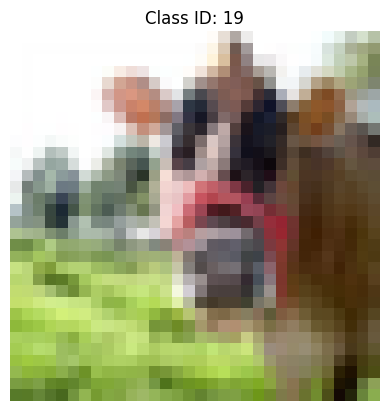

In [ ]:
# Display one sample image
plt.imshow(X_train[0])
plt.title(f"Class ID: {y_train[0][0]}")
plt.axis("off")
plt.show()

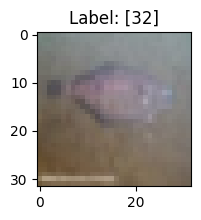

In [ ]:
i = 121
plt.figure(figsize=(2,2))
plt.imshow(X_train[i])
plt.title(f"Label: {y_train[i]}")
plt.show()

# Preprocessing

In [ ]:
# Checking for missing value

print(np.isnan(X_train).sum())
print(np.isnan(X_test).sum())

0
0


In [ ]:
# Check Class Distribution

unique, counts = np.unique(y_train, return_counts=True)

print("Number of Classes :", len(unique))
print("Images per Class :", counts[:10])

Number of Classes : 100
Images per Class : [500 500 500 500 500 500 500 500 500 500]


In [ ]:
# For data augmentation
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

train_datagen.fit(X_train)

# It will help to reduce the overfitting

# Model Building

In [ ]:
# Build Custom CNN Model
model = Sequential()

# Input Layer
model.add(Input(shape=(32,32,3)))

model.add(Conv2D(32, (3,3), padding='same', activation='relu',
                 kernel_initializer=HeNormal(),
                 kernel_regularizer=l2(0.0005)))

# Normalize the feature maps to improve training stability and convergence
model.add(BatchNormalization())

model.add(Conv2D(32, (3,3), padding='same', activation='relu',
                 kernel_initializer=HeNormal(),
                 kernel_regularizer=l2(0.0005)))
model.add(BatchNormalization())

model.add(MaxPooling2D((2,2)))

# Randomly deactivate 25% of neurons to reduce overfitting
model.add(Dropout(0.25))

model.add(Conv2D(64, (3,3), padding='same', activation='relu',
                 kernel_initializer=HeNormal(),
                 kernel_regularizer=l2(0.0005)))
model.add(BatchNormalization())

model.add(Conv2D(64, (3,3), padding='same', activation='relu',
                 kernel_initializer=HeNormal(),
                 kernel_regularizer=l2(0.0005)))
model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.30))

model.add(Conv2D(128, (3,3), padding='same', activation='relu',
                 kernel_initializer=HeNormal(),
                 kernel_regularizer=l2(0.0005)))
model.add(BatchNormalization())

model.add(Conv2D(128, (3,3), padding='same', activation='relu',
                 kernel_initializer=HeNormal(),
                 kernel_regularizer=l2(0.0005)))
model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.40))

# Flatten the feature maps into a 1D vector before passing them to the Dense layer
model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.50))

# Output Layer
model.add(Dense(100, activation='softmax'))

# model.add(BatchNormalization())
# It does not change the image size.
# It only normalizes the values inside each feature map

# MaxPooling2D((2,2))
# It reduces the image size.


In [ ]:
# Display the architecture and summary of the CNN model

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        25,70

 Total params: 839,044 (3.20 MB)

 Trainable params: 838,148 (3.20 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
# Compile the model

model.compile(optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

In [ ]:
# Adding the callbacks

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
monitor="val_loss",
factor=0.2,
patience=2
)

cnn_checkpoint = ModelCheckpoint(
"best_custom_cnn.keras",
monitor='val_accuracy',
save_best_only=True
)

In [ ]:
# Create batches of augmented training images

train_generator = train_datagen.flow(
    X_train, y_train, batch_size=64)

In [ ]:
# Train the model

history = model.fit(
    train_generator,
    epochs=5,
    validation_data=(X_test, y_test),
    callbacks=[early_stop,  reduce_lr, cnn_checkpoint])

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 496s 620ms/step - accuracy: 0.0202 - loss: 4.9674 - val_accuracy: 0.0353 - val_loss: 4.7448 - learning_rate: 0.0010
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 485s 621ms/step - accuracy: 0.0340 - loss: 4.6967 - val_accuracy: 0.0648 - val_loss: 4.4203 - learning_rate: 0.0010
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 479s 612ms/step - accuracy: 0.0415 - loss: 4.4975 - val_accuracy: 0.0668 - val_loss: 4.2861 - learning_rate: 0.0010
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 508s 620ms/step - accuracy: 0.0523 - loss: 4.3241 - val_accuracy: 0.0958 - val_loss: 4.0362 - learning_rate: 0.0010
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 489s 626ms/step - accuracy: 0.0646 - loss: 4.1912 - val_accuracy: 0.1012 - val_loss: 3.9622 - learning_rate: 0.0010


In [ ]:
# Evaluate the trained model on the test dataset

test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 65ms/step - accuracy: 0.1012 - loss: 3.9622
Test Loss : 3.962185859680176
Test Accuracy : 0.10119999945163727


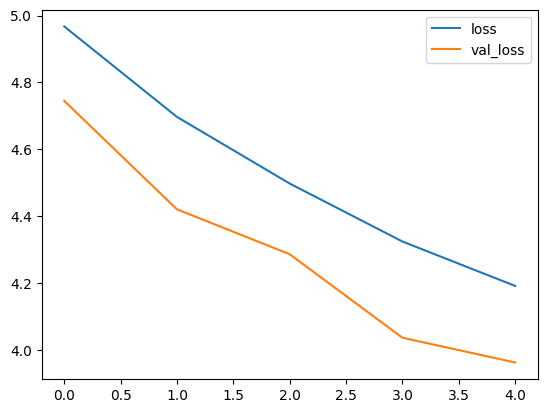

In [ ]:
# Plot loss and val_loss

plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

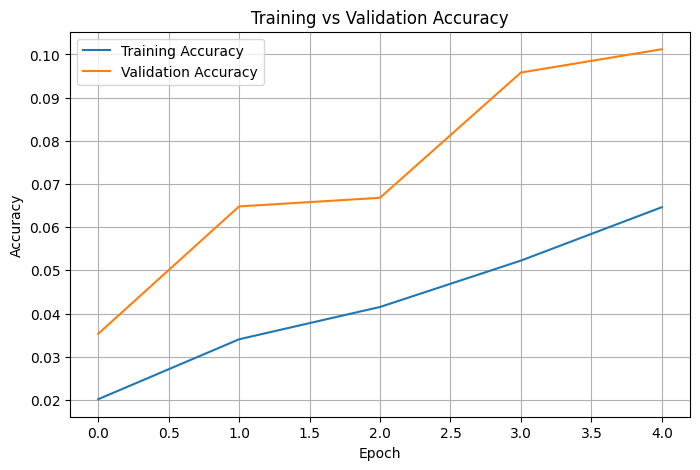

In [ ]:
# Plot training and validation accuracy

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

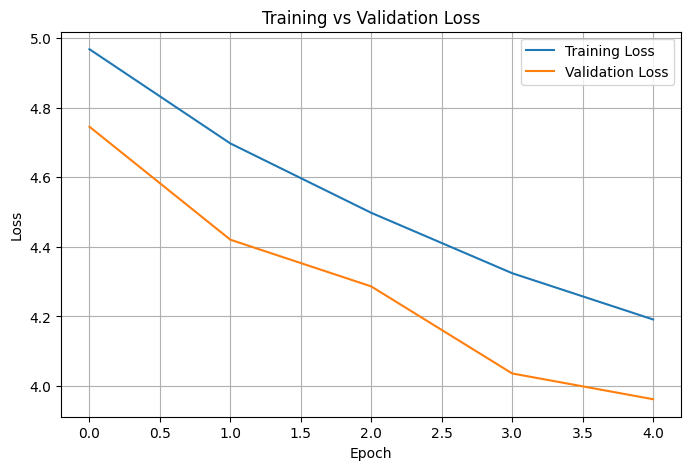

In [ ]:
# Plot training and validation loss

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Predict class probabilities for the test images

y_pred = model.predict(X_test)

# Convert probabilities to predicted class labels

y_pred_classes = np.argmax(y_pred, axis=1)

# Convert true labels to 1D

y_true = y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 68ms/step


In [ ]:
# Display precision, recall, and F1-score for each class

print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.17      0.24      0.20       100
           1       0.00      0.00      0.00       100
           2       0.00      0.00      0.00       100
           3       0.00      0.00      0.00       100
           4       0.00      0.00      0.00       100
           5       0.10      0.01      0.02       100
           6       0.10      0.17      0.12       100
           7       0.00      0.00      0.00       100
           8       0.00      0.00      0.00       100
           9       0.09      0.02      0.03       100
          10       0.00      0.00      0.00       100
          11       0.00      0.00      0.00       100
          12       0.11      0.18      0.13       100
          13       0.07      0.16      0.09       100
          14       0.04      0.01      0.02       100
          15       0.00      0.00      0.00       100
          16       0.04      0.06      0.05       100
          17       0.14    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


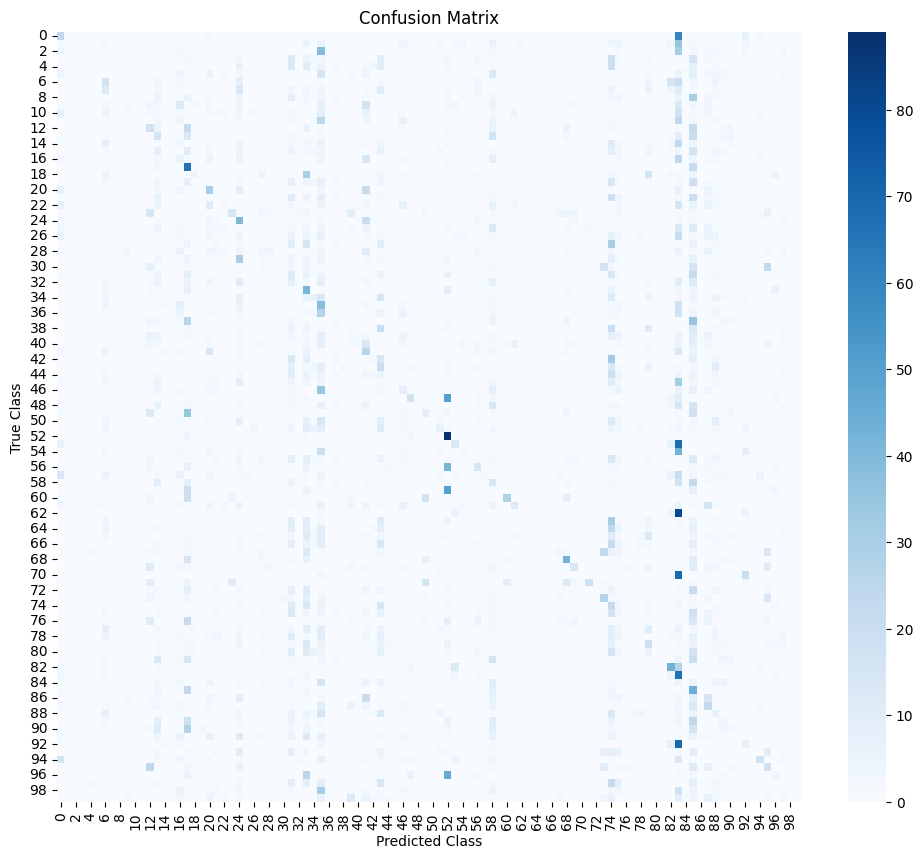

In [ ]:
# Compute the confusion matrix

cm = confusion_matrix(y_true, y_pred_classes)

# Plot the confusion matrix

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.show()

In [ ]:
# Save the models weights and architecture to a Keras file

model.save('model_weights.keras')

In [ ]:
# Reshape the 121st test image to batch size 1 (32x32 pixels, 3 color channels) and get model predictions

pred_probs = model.predict(X_test[121].reshape(1,32,32,3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


In [ ]:
# Get the index (class label) with the highest predicted probability

sample_pred = np.argmax(pred_probs)

In [ ]:
# Print

print(sample_pred)

83


In [ ]:
# Free the memory before building the VGG model

del history

import gc
gc.collect()

tf.keras.backend.clear_session()

In [ ]:
# Automatically optimize data loading

AUTOTUNE = tf.data.AUTOTUNE

# Resize Images Batch-by-Batch

IMG_SIZE = 96

def preprocess(image,label):

    image = tf.image.resize(image,(IMG_SIZE,IMG_SIZE))

    return image,label

train_vgg = tf.data.Dataset.from_tensor_slices((X_train,y_train))

train_vgg = train_vgg.map(preprocess,
                          num_parallel_calls=AUTOTUNE)

train_vgg = train_vgg.shuffle(5000)\
                     .batch(16)\
                     .prefetch(AUTOTUNE)

test_vgg = tf.data.Dataset.from_tensor_slices((X_test,y_test))

test_vgg = test_vgg.map(preprocess,
                        num_parallel_calls=AUTOTUNE)

test_vgg = test_vgg.batch(16)\
                   .prefetch(AUTOTUNE)

In [ ]:
# Load the pre-trained VGG16 model without the top classification layer

vgg_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(96,96,3))

In [ ]:
# Freeze the convolutional layers

vgg_base.trainable = False

In [ ]:
# Build the VGG16 model

vgg_model = Sequential()

# Input Layer
vgg_model.add(Input(shape=(96,96,3)))

# Add the VGG16 base model
vgg_model.add(vgg_base)

# Reduces parameters and memory usage.
vgg_model.add(GlobalAveragePooling2D())

# Fully Connected Layer
vgg_model.add(Dense(256, activation='relu'))

# Apply dropout to reduce overfitting
vgg_model.add(Dropout(0.5))

# Output Layer for CIFAR-100
vgg_model.add(Dense(100, activation='softmax'))

In [ ]:
# Compile the VGG16 model

vgg_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

In [ ]:
# Display the VGG16 model architecture

vgg_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,871,716 (56.73 MB)

 Trainable params: 157,028 (613.39 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# Callbacks

early_stop = EarlyStopping(
monitor="val_loss", patience=2,
restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(
monitor="val_loss", factor=0.2,
patience=2)

checkpoint = ModelCheckpoint(
"best_vgg.keras", save_best_only=True)

In [ ]:
# Testing generator

test_datagen_vgg = ImageDataGenerator(
    preprocessing_function=lambda x: tf.image.resize(x, (96, 96)))

test_generator_vgg = test_datagen_vgg.flow(X_test,
    y_test, batch_size=32, shuffle=False)

In [ ]:
# Train the VGG16 model

history_vgg = vgg_model.fit(train_vgg,
                            validation_data=test_vgg,epochs=5,
                            callbacks=[early_stop,reduce_lr,checkpoint])

Epoch 1/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 5811s 2s/step - accuracy: 0.0741 - loss: 4.2312 - val_accuracy: 0.1982 - val_loss: 3.7330 - learning_rate: 1.0000e-04
Epoch 2/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 5890s 2s/step - accuracy: 0.1569 - loss: 3.6300 - val_accuracy: 0.2538 - val_loss: 3.2960 - learning_rate: 1.0000e-04
Epoch 3/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 5838s 2s/step - accuracy: 0.2008 - loss: 3.3439 - val_accuracy: 0.2853 - val_loss: 3.0689 - learning_rate: 1.0000e-04
Epoch 4/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 5784s 2s/step - accuracy: 0.2288 - loss: 3.1642 - val_accuracy: 0.3066 - val_loss: 2.9163 - learning_rate: 1.0000e-04
Epoch 5/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 5781s 2s/step - accuracy: 0.2540 - loss: 3.0398 - val_accuracy: 0.3191 - val_loss: 2.8127 - learning_rate: 1.0000e-04


In [ ]:
# Evaluate the trained VGG16 model

test_loss, test_accuracy = vgg_model.evaluate(test_vgg)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

625/625 ━━━━━━━━━━━━━━━━━━━━ 964s 2s/step - accuracy: 0.3191 - loss: 2.8127
Test Loss: 2.8127124309539795
Test Accuracy: 0.3190999925136566


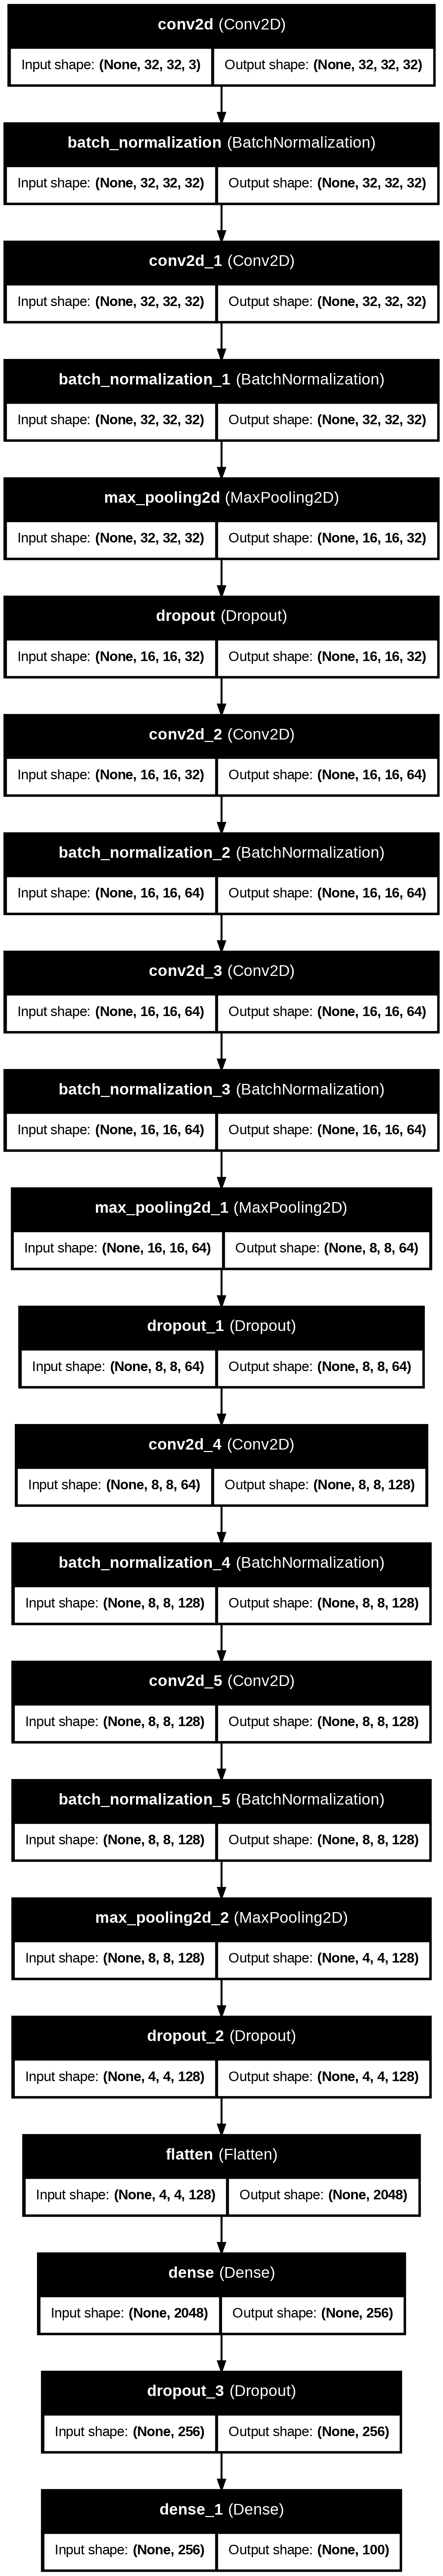

In [ ]:
# Custom CNN Plot

plot_model(model,
    show_shapes=True,
    show_layer_names=True,
    to_file="CustomCNN.png")

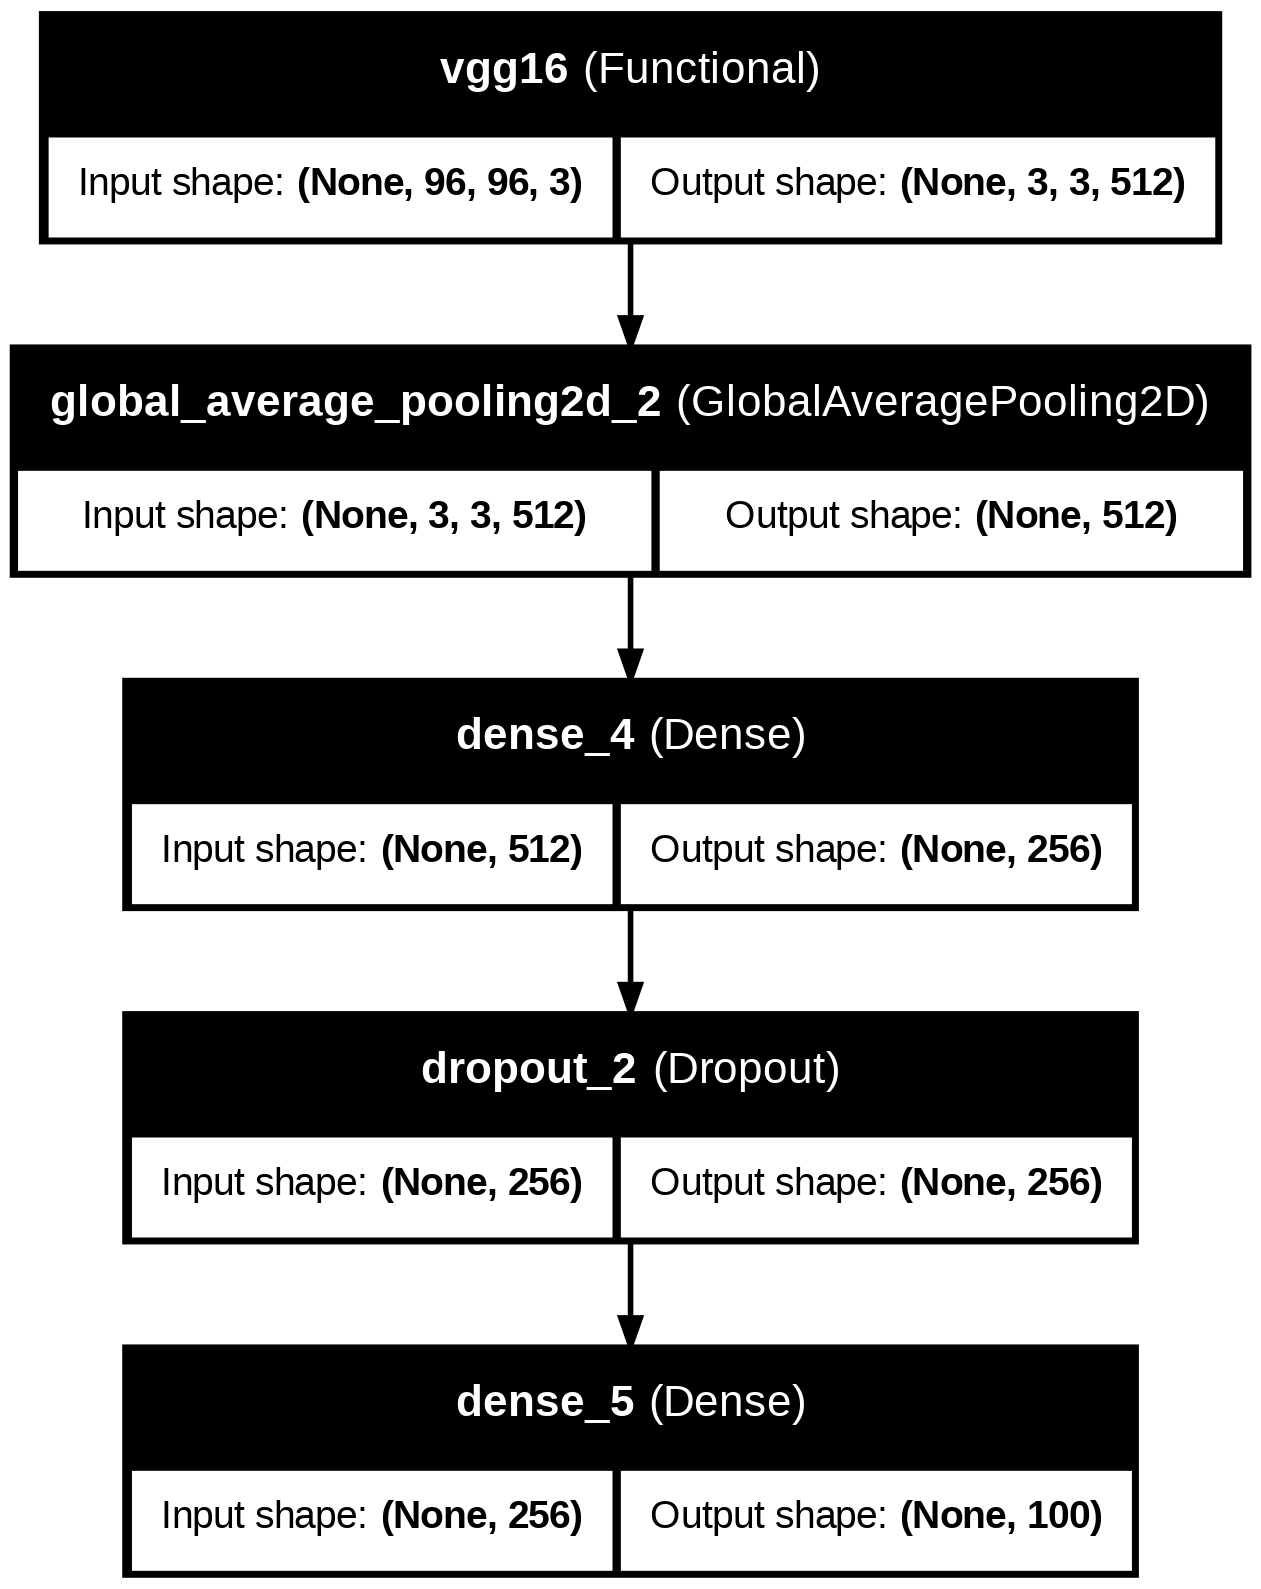

In [ ]:
# Custom VGG16 Plot

plot_model(vgg_model,
    show_shapes=True,
    show_layer_names=True,
    to_file="VGG16.png")

In [ ]:
# Summaries of the model

custom_test_loss, custom_test_accuracy = model.evaluate(test_generator)

print("Custom CNN Test Accuracy :", custom_test_accuracy)
print("VGG16 Test Accuracy      :", test_accuracy)

print("CUSTOM CNN")
model.summary()

print("\nVGG16")
vgg_model.summary()

In [ ]:
# Compare table for Accuracy

vgg_test_loss, vgg_test_accuracy = vgg_model.evaluate(test_generator_vgg)
comparison = pd.DataFrame({"Model":["VGG16"], "Test Accuracy":[vgg_test_accuracy]})
comparison = pd.DataFrame({"Model":["Custom CNN", "VGG16"],
    "Test Accuracy":[custom_test_accuracy,vgg_test_accuracy]})

In [ ]:
# Final Test Accuracy Plot

comparison.plot(x="Model", y="Test Accuracy",
    kind="bar", legend=False,
    title="Final Test Accuracy Comparison")

In [ ]:
# The Combined Accuracy Curve

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],label='CNN Train')
plt.plot(history.history['val_accuracy'],label='CNN Validation')

plt.plot(history_vgg.history['accuracy'],label='VGG Train')
plt.plot(history_vgg.history['val_accuracy'],label='VGG Validation')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.legend()
plt.show()

In [ ]:
# The Combined Loss Curve

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],label='CNN Train')
plt.plot(history.history['val_loss'],label='CNN Validation')

plt.plot(history_vgg.history['loss'],label='VGG Train')
plt.plot(history_vgg.history['val_loss'],label='VGG Validation')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Comparison")
plt.legend()
plt.show()


In [ ]:
# The final comparison table

comparison = pd.DataFrame({
    "Model":["Custom CNN","VGG16"],
    "Test Accuracy":[custom_test_accuracy,vgg_test_accuracy],
    "Test Loss":[custom_test_loss,vgg_test_loss]})

print(comparison)